In [1]:
%%capture
%pip install pandas seaborn xgboost scikit-learn joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import pickle
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score
warnings.filterwarnings('ignore')

1. Wczytanie danych

In [2]:
X_train = pd.read_csv('X_train.csv')
X_test = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv').values.ravel()
y_test = pd.read_csv('y_test.csv').values.ravel()

2. Random Forest z analizą OOB

Analiza błędu OOB dla Lasu Losowego...


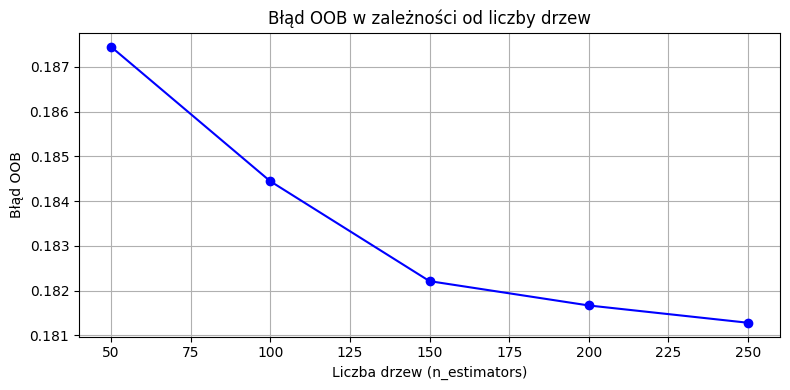

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_true, y_pred)` to use acustom metric. Only available if `bootstrap=True`.For an illustration of out-of-bag (OOB) error estimation, see the example:ref:`sphx_glr_auto_examples_ensemble_plot_ensemble_oob.py`.",True
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.

In [3]:
print("Analiza błędu OOB dla Lasu Losowego...")
n_estimators_range = [50, 100, 150, 200, 250]
oob_errors = []

for n in n_estimators_range:
    rf = RandomForestClassifier(n_estimators=n, oob_score=True, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    oob_errors.append(1 - rf.oob_score_)

plt.figure(figsize=(8, 4))
plt.plot(n_estimators_range, oob_errors, marker='o', linestyle='-', color='b')
plt.title('Błąd OOB w zależności od liczby drzew')
plt.xlabel('Liczba drzew (n_estimators)')
plt.ylabel('Błąd OOB')
plt.grid(True)
plt.tight_layout()
plt.show()
# Wybór najlepszego Lasu
best_rf = RandomForestClassifier(n_estimators=200, oob_score=True, random_state=42, n_jobs=-1)
best_rf.fit(X_train, y_train)

3. XGBoost z regularyzacją

In [4]:
print("Trenowanie XGBoost...")
xgb_params = {
    'learning_rate': [0.05, 0.1],
    'max_depth': [4, 6],
    'subsample': [0.8, 1.0],
    'reg_alpha': [0, 0.1]
}

xgb_base = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_grid = GridSearchCV(xgb_base, xgb_params, cv=3, scoring='accuracy', n_jobs=-1)
xgb_grid.fit(X_train, y_train)
best_xgb = xgb_grid.best_estimator_

Trenowanie XGBoost...


4. Tabela Sumaryczna

In [5]:
def get_metrics(model, X, y):
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]
    tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()
    acc = accuracy_score(y, y_pred)
    sens = tp / (tp + fn)
    spec = tn / (tn + fp)
    auc = roc_auc_score(y, y_proba)
    return {'Accuracy': acc, 'Sensitivity': sens, 'Specificity': spec, 'AUC': auc}

summary_data = {
    'Random Forest': get_metrics(best_rf, X_test, y_test),
    'XGBoost': get_metrics(best_xgb, X_test, y_test)
}
summary_df = pd.DataFrame(summary_data).T
display(summary_df.style.format("{:.3f}"))

summary_df.to_csv('tabela_wynikow.csv')


,Accuracy,Sensitivity,Specificity,AUC
Random Forest,0.821,0.558,0.920,0.860
XGBoost,0.817,0.505,0.934,0.855


5. Wizualizacje dla Worda (ROC i Importance)

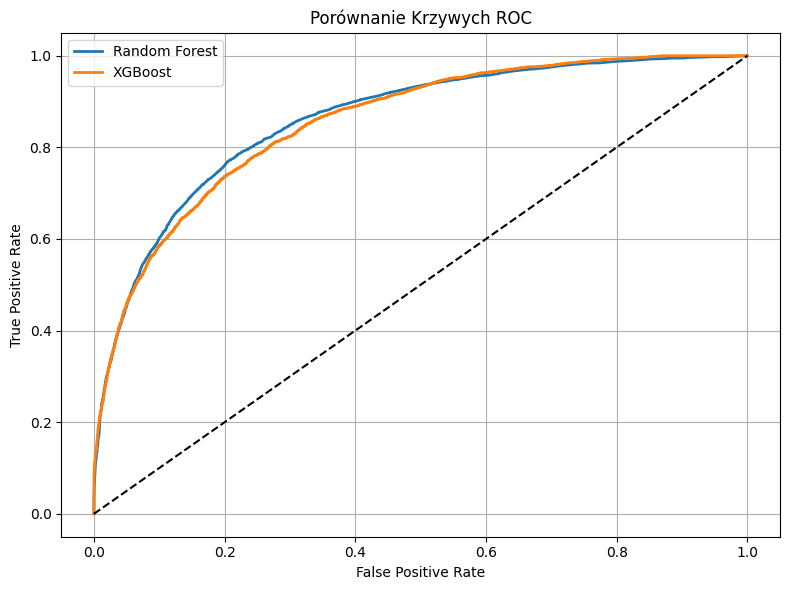

In [6]:
plt.figure(figsize=(8, 6))
# 
fpr_rf, tpr_rf, _ = roc_curve(y_test, best_rf.predict_proba(X_test)[:, 1])
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, best_xgb.predict_proba(X_test)[:, 1])
plt.plot(fpr_rf, tpr_rf, label='Random Forest', linewidth=2)
plt.plot(fpr_xgb, tpr_xgb, label='XGBoost', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--')
plt.title('Porównanie Krzywych ROC')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

6. Zapis modelu

In [7]:
# Format 1: Joblib
joblib.dump(best_xgb, 'best_ensemble_model.joblib')
# Format 2: Pickle
with open('best_ensemble_model.pkl', 'wb') as f:
    pickle.dump(best_xgb, f)
print("Modele zapisane: .joblib oraz .pkl")

Modele zapisane: .joblib oraz .pkl
